In [2]:
#unhashtag this to install required libraries
%pip install pandas numpy matplotlib scikit-learn

import sys
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import ops
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision
from sklearn.preprocessing import StandardScaler
print(tf.__version__)



Note: you may need to restart the kernel to use updated packages.
2.16.2


In [3]:
#importing datasets
#at minimum include “Age”, “BMI”, and “Blood Glucose Level”

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train = train.drop(train.columns[0], axis=1)
test = test.drop(test.columns[0], axis=1)

#Scaling continuous variables for easier use in model
#Binary columns are already created via preprocessing.
def separate_cols(x):
    bin_col = pd.DataFrame()
    cont_col = pd.DataFrame()
    for col in x.columns:
        if x[col].nunique()!= 2:
            bin_col[col] = x[col].values
        else:
            cont_col[col] = x[col].values
    return bin_col, cont_col

train_bin, train_col = separate_cols(train)
test_bin, test_col = separate_cols(test)

scaled=sc.fit_transform(train_bin)
scaled_te = sc.transform(test_bin)
scaled_tr_bin = pd.DataFrame(scaled, columns = train_bin.columns)
scaled_te_bin = pd.DataFrame(scaled_te, columns = test_bin.columns)

x_train = pd.concat([scaled_tr_bin, train_col], axis = 1)
x_test = pd.concat([scaled_te_bin, test_col], axis = 1)

print(x_train)

target = "HbA1c_level"
#training matrix
#x_train = 
#x_test = 
#testing matrix
y_train, y_test = train[target],test[target]
y_train = train["HbA1c_level"].astype("float32").values
y_test  = test["HbA1c_level"].astype("float32").values


#print(x_train)
#print(y_train)
#print(x_train.shape[1])

            age       bmi  HbA1c_level  blood_glucose_level  hypertension  \
0      0.141014  2.521511    -1.429243             1.514969             1   
1      0.141014  0.390141     0.435572             0.486562             0   
2      0.674635  0.403462     2.486868             2.984121             1   
3      1.697407 -0.447605     0.622053             0.486562             0   
4     -0.926226  0.829736    -0.683317             0.045817             0   
...         ...       ...          ...                  ...           ...   
76884  0.363356  1.198286    -0.683317            -0.296985             0   
76885 -0.792821 -0.373600     0.435572             0.413105             0   
76886  0.808040  1.550554     0.901776             0.511048             0   
76887 -1.326441  0.000870     0.435572             0.168246             0   
76888 -1.815593 -1.800433     0.528813             1.514969             0   

       heart_disease  diabetes  female  male  other  current  ever  former 

In [4]:
### Creating Sequential Model ###

model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(x_train.shape[1],)),
        tf.keras.layers.Dense(14, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ]
)

#x = ops.ones((4, 4))
#y = model(x)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           238 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253 (1012.00 B)

 Trainable params: 253 (1012.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Compiling
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=10)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
ann = model.fit(x_train,y_train,batch_size=64, epochs=100, validation_split=0.2, callbacks=[callback])


Epoch 1/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.3076 - mae: 1.4164 - val_loss: 0.0583 - val_mae: 0.1620
Epoch 2/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0254 - mae: 0.0980 - val_loss: 0.0131 - val_mae: 0.0727
Epoch 3/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0087 - mae: 0.0609 - val_loss: 0.0061 - val_mae: 0.0522
Epoch 4/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0043 - mae: 0.0442 - val_loss: 0.0030 - val_mae: 0.0356
Epoch 5/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0019 - mae: 0.0277 - val_loss: 0.0013 - val_mae: 0.0210
Epoch 6/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.8544e-04 - mae: 0.0158 - val_loss: 5.8147e-04 - val_mae: 0.0127
Epoch 7/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.4625e-04 - mae: 0.0101 - val_loss: 2.8119e-04 - val_mae: 0.0080
Epoch 8/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5682e-04 - mae: 0.0066 - val_loss: 1.3500e-04 - val_mae: 0.0051
Epoch 9/100
962/962 ━━━━

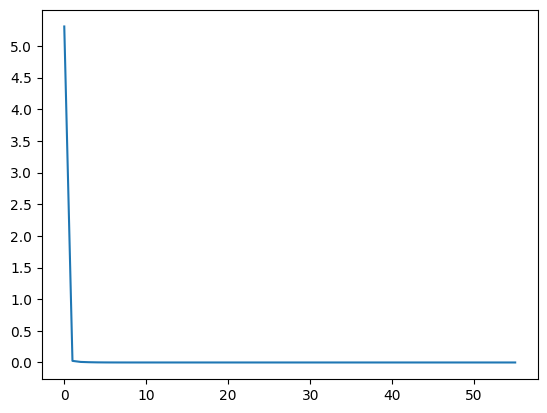

In [6]:
import matplotlib.pyplot as plt
y_ticks = np.arange(0, max(ann.history["loss"]), 0.5)
plt.plot(ann.history["loss"])
plt.yticks(y_ticks)
plt.show()

#print(max(ann.history["loss"]))

In [7]:
#Testing the data
#loss, accuracy = model.evaluate(x_test,y_test,verbose=1)
y_pred = model.predict(x_test,verbose=0).squeeze()
print("Predictions: ", y_pred)

y_pred_df = pd.DataFrame({"y prediction": y_pred})
y_test_df = pd.DataFrame({"y testing": y_test})
predictions = pd.concat([y_pred_df, y_test_df], axis=1)
print(predictions)
#print(y_test)


Predictions:  [6.599646  4.8003364 5.0002294 ... 5.8004384 5.999152  6.499793 ]
       y prediction  y testing
0          6.599646        6.6
1          4.800336        4.8
2          5.000229        5.0
3          6.099741        6.1
4          6.099913        6.1
...             ...        ...
19218      4.000231        4.0
19219      6.200028        6.2
19220      5.800438        5.8
19221      5.999152        6.0
19222      6.499793        6.5

[19223 rows x 2 columns]


In [8]:
#Writing predictions into csv

predictions.to_csv("prediction_continuous.csv", index=False)

pd.DataFrame(ann.history).to_csv("training_hba1c.csv", index=False)

In [9]:
#from sklearn.linear_model import LinearRegression
#reg = LinearRegression().fit(x_train, y_train)
#print("Baseline R^2 (train):", reg.score(x_train, y_train))
#print("Baseline R^2 (test):", reg.score(x_test, y_test))
